In [28]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import List
from langgraph.checkpoint.memory import MemorySaver

In [19]:
llm = ChatOllama(
    model="llama3.2:3b"
)
llm

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, model='llama3.2:3b')

In [20]:
# llm = ChatGoogleGenerativeAI(model="chat-bison@001")
# llm

In [13]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [15]:
def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

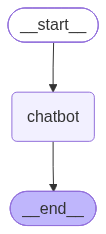

In [34]:
checkpoint = MemorySaver()

graph_builder = StateGraph(ChatState)

# Add the chatbot node to the graph
graph_builder.add_node("chatbot", chat_node)

# Connect the start and end nodes to the chatbot node
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compile the graph
chat_bot= graph_builder.compile(checkpointer=checkpoint)
chat_bot

In [33]:
initial_state = {
    "messages" : [HumanMessage(content="What is Encapsulation in OOp Python?")]
}

response = chat_bot.invoke(initial_state)

In [22]:
response

{'messages': [HumanMessage(content='What is Encapsulation in OOp Python?', additional_kwargs={}, response_metadata={}, id='1dc4ecbd-d4cd-4fca-ac74-1509e851dcc2'),
  AIMessage(content='Encapsulation in OOP (Object-Oriented Programming) is a fundamental concept that binds together the data and the methods that manipulate that data. In Python, encapsulation is achieved through the use of classes and objects.\n\nEncapsulation involves:\n\n1.  Hiding the implementation details of an object from the outside world.\n2.  Exposing only the necessary information through public methods.\n3.  Controlling access to the object\'s internal state.\n\nIn Python, encapsulation is achieved by defining a class with private variables (prefixed with double underscore `__`) and providing public methods to access and modify these variables.\n\nHere\'s an example of encapsulation in Python:\n\n```python\nclass BankAccount:\n    def __init__(self, balance=0):\n        self.__balance = balance  # Private variabl

In [24]:
response["messages"][-1].content

'Encapsulation in OOP (Object-Oriented Programming) is a fundamental concept that binds together the data and the methods that manipulate that data. In Python, encapsulation is achieved through the use of classes and objects.\n\nEncapsulation involves:\n\n1.  Hiding the implementation details of an object from the outside world.\n2.  Exposing only the necessary information through public methods.\n3.  Controlling access to the object\'s internal state.\n\nIn Python, encapsulation is achieved by defining a class with private variables (prefixed with double underscore `__`) and providing public methods to access and modify these variables.\n\nHere\'s an example of encapsulation in Python:\n\n```python\nclass BankAccount:\n    def __init__(self, balance=0):\n        self.__balance = balance  # Private variable\n\n    def deposit(self, amount):\n        if amount > 0:\n            self.__balance += amount\n            print(f"Deposited ${amount}. New balance: ${self.__balance}")\n        e

In [35]:
config = {"configurable" : {"thread_id" : "thread-1"}}

while True:
    user_input = input("User: ")
    if user_input.lower() in ["exit", "quit", "bye"]:
        break
    config = {"configurable" : {"thread_id" : "thread-1"}}
    response = chat_bot.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)
    print("AI:", response["messages"][-1].content)

AI: Hello Taufiq! Nice to meet you too! It's great to have you here. Is there anything I can help you with or would you like to chat?
AI: At the very beginning, when we started chatting, you said: "hello my name is taufiq nice to meet you".

You introduced yourself with a friendly message!
